Epoch 0, Loss: 0.699884
Epoch 5000, Loss: 0.001503
Epoch 10000, Loss: 0.000652
Epoch 15000, Loss: 0.000414


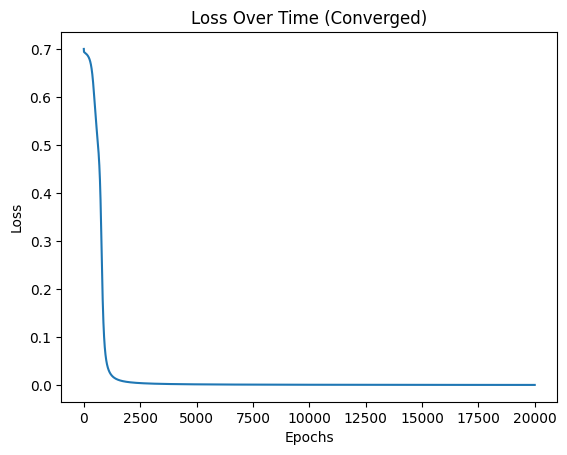


Final Probabilities:
 [[2.10311728e-04 9.99602803e-01 9.99600200e-01 2.00553849e-04]]
Final Predictions (XOR):
 [[0 1 1 0]]


In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Define the Sigmoid Activation Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize the parameters (weights and biases) for the neural network
# Using 1.0 scale instead of 0.01 to prevent vanishing gradients during initialization
def initializeParameters(inputFeatures, n_h1, n_h2, outputFeatures):
    np.random.seed(42) # For reproducibility
    W1 = np.random.randn(n_h1, inputFeatures) * 1.0 # Weights for hidden layer 1
    b1 = np.zeros((n_h1, 1)) # Biases for hidden layer 1
    W2 = np.random.randn(n_h2, n_h1) * 1.0 # Weights for hidden layer 2
    b2 = np.zeros((n_h2, 1)) # Biases for hidden layer 2
    W3 = np.random.randn(outputFeatures, n_h2) * 1.0 # Weights for output layer
    b3 = np.zeros((outputFeatures, 1)) # Biases for output layer

    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}
    return parameters

# Perform Forward Propagation to calculate predictions and loss
def forwardPropagation(X, Y, parameters):
    m = X.shape[1] # Number of training examples

    # Layer 1
    Z1 = np.dot(parameters["W1"], X) + parameters["b1"] # Linear combination
    A1 = sigmoid(Z1) # Activation function output

    # Layer 2
    Z2 = np.dot(parameters["W2"], A1) + parameters["b2"] # Linear combination
    A2 = sigmoid(Z2) # Activation function output

    # Output Layer
    Z3 = np.dot(parameters["W3"], A2) + parameters["b3"] # Linear combination
    A3 = sigmoid(Z3) # Final activation function output (predictions)

    cache = (X, Z1, A1, Z2, A2, Z3, A3) # Store intermediate values for backpropagation

    # Calculate the Cross-Entropy Loss (added epsilon to prevent log(0) errors)
    logprobs = np.multiply(np.log(A3 + 1e-15), Y) + np.multiply(np.log(1 - A3 + 1e-15), (1 - Y))
    cost = -np.sum(logprobs) / m
    return cost, cache, A3

# Perform Backward Propagation to calculate gradients
def backwardPropagation(Y, cache, parameters):
    m = Y.shape[1] # Number of training examples
    (X, Z1, A1, Z2, A2, Z3, A3) = cache # Retrieve intermediate values from cache

    # Layer 3 Gradients (Output Layer)
    dZ3 = A3 - Y # Derivative of loss with respect to Z3
    dW3 = np.dot(dZ3, A2.T) / m # Gradient of weights W3
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m # Gradient of biases b3

    # Layer 2 Gradients (Hidden Layer 2)
    dA2 = np.dot(parameters["W3"].T, dZ3) # Derivative of loss with respect to A2
    dZ2 = dA2 * (A2 * (1 - A2)) # Derivative of loss with respect to Z2 (sigmoid derivative)
    dW2 = np.dot(dZ2, A1.T) / m # Gradient of weights W2
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m # Gradient of biases b2

    # Layer 1 Gradients (Hidden Layer 1)
    dA1 = np.dot(parameters["W2"].T, dZ2) # Derivative of loss with respect to A1
    dZ1 = dA1 * (A1 * (1 - A1)) # Derivative of loss with respect to Z1 (sigmoid derivative)
    dW1 = np.dot(dZ1, X.T) / m # Gradient of weights W1
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m # Gradient of biases b1

    gradients = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}
    return gradients

# Update the model parameters using calculated gradients and learning rate
def updateParameters(parameters, gradients, learningRate):
    # Iterate through all parameters (W1, b1, W2, b2, W3, b3) and update them
    for key in parameters:
        parameters[key] -= learningRate * gradients["d" + key] # Parameter = Parameter - learningRate * Gradient
    return parameters

# Setup XOR Data for training
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]]) # Input features
Y = np.array([[0, 1, 1, 0]]) # True labels (XOR output)

# Model Hyperparameters Configuration
parameters = initializeParameters(inputFeatures=2, n_h1=4, n_h2=4, outputFeatures=1) # Initialize W, b
epochs = 20000 # Number of training iterations
learningRate = 0.5 # Learning rate for gradient descent (higher for XOR)
losses = [] # List to store loss at each epoch

# Training Loop
for i in range(epochs):
    # Step 1: Forward Propagation
    cost, cache, A3 = forwardPropagation(X, Y, parameters)
    # Step 2: Backward Propagation
    gradients = backwardPropagation(Y, cache, parameters)
    # Step 3: Update Parameters
    parameters = updateParameters(parameters, gradients, learningRate)
    losses.append(cost) # Store the loss

    # Print loss periodically
    if i % 5000 == 0:
        print(f"Epoch {i}, Loss: {cost:.6f}")

# Plotting the loss over time to visualize convergence
plt.plot(losses)
plt.title("Loss Over Time (Converged)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Make final predictions and display results
_, _, final_output = forwardPropagation(X, Y, parameters) # Get predictions from the trained model
print("\nFinal Probabilities:\n", final_output)
print("Final Predictions (XOR):\n", (final_output > 0.5).astype(int)) # Convert probabilities to binary predictions
